# Level 2: Intermediate Machine Learning
## Task 1: Logistic Regression for Binary Classification
**Dataset:** Customer Churn Prediction Dataset

### 1. Load and Preprocess the Dataset
Loading the customer churn dataset. We will encode categorical variables (like State and Plan types) using One-Hot Encoding (`pd.get_dummies`), and encode the target variable using `LabelEncoder`. Finally, we will scale the features using `StandardScaler`.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc

# Load the dataset
df = pd.read_csv(r'D:\AI\Ai_intern\Data Set For Task\Churn Prdiction Data\churn-bigml-80.csv')

# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)
y_raw = df['Churn']

# Encode categorical features (converts text columns into numerical format)
X_encoded = pd.get_dummies(X, drop_first=True)

# Encode the target variable (False -> 0, True -> 1)
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Original features shape: {X.shape}")
print(f"Encoded features shape: {X_encoded.shape}")
print(f"Training data shape: {X_train_scaled.shape}")

Original features shape: (2666, 19)
Encoded features shape: (2666, 68)
Training data shape: (2132, 68)


In [37]:
y_encoded

array([0, 0, 0, ..., 0, 0, 0], shape=(2666,))

### 2. Train the Logistic Regression Model
Training a simple Logistic Regression model on the scaled training data. We set `max_iter=1000` to ensure the algorithm converges successfully.

In [29]:
# Initialize and train the Logistic Regression model
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### 3. Evaluate the Model
Evaluating model performance using Accuracy, Precision, Recall, and plotting the Receiver Operating Characteristic (ROC) curve to visualize the tradeoff between the true positive rate and false positive rate.

Accuracy:  0.8408
Precision: 0.4318
Recall:    0.2405


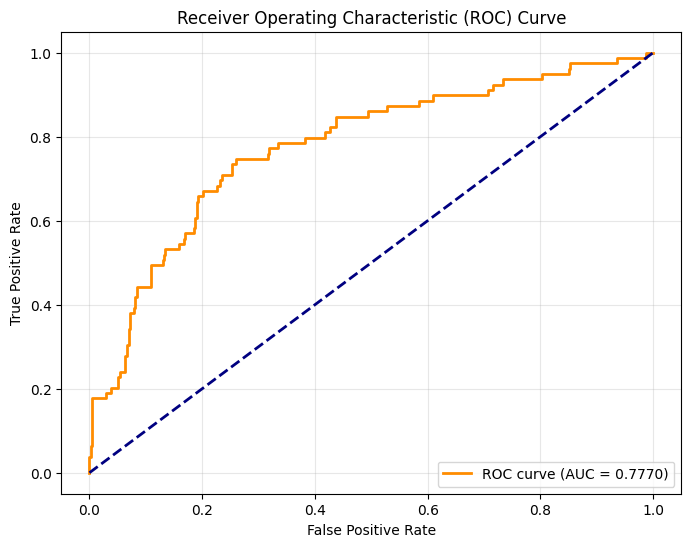

In [30]:
# Make predictions and get probabilities
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

# Calculate and print metrics
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")

# Generate ROC curve data
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

### 4. Interpret Model Coefficients and Odds Ratio
Analyzing the coefficients to determine which features have the highest impact on customer churn. An odds ratio greater than 1 increases the likelihood of a customer churning.

In [31]:
# Calculate Odds Ratio
odds_ratios = np.exp(log_model.coef_[0])

# Create a DataFrame for feature importance using the encoded columns
coef_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': log_model.coef_[0],
    'Odds Ratio': odds_ratios
})

# Sort by absolute coefficient value to find the most impactful features
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).drop('Abs_Coefficient', axis=1)

print("--- Top 10 Features Impacting Customer Churn ---")
print(coef_df.head(10))

--- Top 10 Features Impacting Customer Churn ---
                   Feature  Coefficient  Odds Ratio
67     Voice mail plan_Yes    -0.842816    0.430497
66  International plan_Yes     0.739731    2.095371
15  Customer service calls     0.675465    1.964946
2    Number vmail messages     0.391205    1.478762
3        Total day minutes     0.388295    1.474465
5         Total day charge     0.387411    1.473161
13        Total intl calls    -0.309195    0.734038
58                State_TX     0.265246    1.303752
41                State_MT     0.223290    1.250183
55                State_SC     0.199504    1.220797
